### Bitacora 1: Modificaciones e nivelacion del avance del proyecto
- Correccion de los archivos del entrenamiento...... listo!
- Crear un archivo que haga un torneo que gane el mejor agente con la dinamica de todos contra todos........Listo!
y me liste el primer lugar, segundo y tercer lugar
se requiere que cada 100 epocas se haga un torneo y se guarde solo el mejor modelo o agente..... Eso lo hago manualmente
- Desechar los demas modelos a excepcion del tecer y segundo lugar, para tener un mejor control de los modelos guardados
luego de haber llegado a las 500 epocas...... se lo hara manualmente
- mejorar las graficas de trainRL para que ver si existe una mejora cosiderable en el entrenamiento........ Listo!
- hacer pruebas alterando los parametros del modelo y del entorno para ver si se puede mejorar el rendimiento del agente..... con las mejoras se logro una leve mejora!
sacar conclusiones de los resultados obtenidos con las temperaturas de 0.1, 0.5, 0.01 y 1........ Mejoras implementadas de una mejor manera!
- hacer un control por medio de checkpoints para corregir errores en el entrenamiento y no perder todo el avance



In [19]:
print('Bitacora 1: Modificaciones e nivelacion del avance del proyecto')

Bitacora 1: Modificaciones e nivelacion del avance del proyecto


1.- Saber en donde se estan guardando los modelos entrenados (agentes).... Listo!

2.- crear una copia de trainRL.py para hacer las modificaciones necesarias sin afectar el archivo original......... Listo!

2.2.1.- integrar las graficas para verificar si el entrenamiento es valido.......... Listo!

2.2.2.- variar los parametros de aprendizaje cada 100 epocas para ver si se mejora el rendimiento del agente...... Listo!, Se implemento ciertas mejoras en el entrenamiento

3.- crear un archivo torneo.py que haga el torneo entre los agentes guardados cada 100 que yo mismo los elija con la consola con temperaturas de 0.1, 0.5, 0.01 y 1............ listo!

4.- crar un archivo torneo_paralelo.py que haga el torneo usando todos los nucleos fisicos del procesador con las mismas caracteristicas del archivo torneo.py.... listo!

5.- Identificar los archivos a desechar despues de cada torneo para guardar solo el mejor luego de cada 500 epocas de entrenamiento ....... eso se hace manualmente!

6.- evidenciar los resultados obtenidos en este desarrollo

7.- iniciar un nuevo entrenamiento con otro torneo con los 3 mejores agentes guardados y se guarda solo el mejor agente luego de 500 epocas


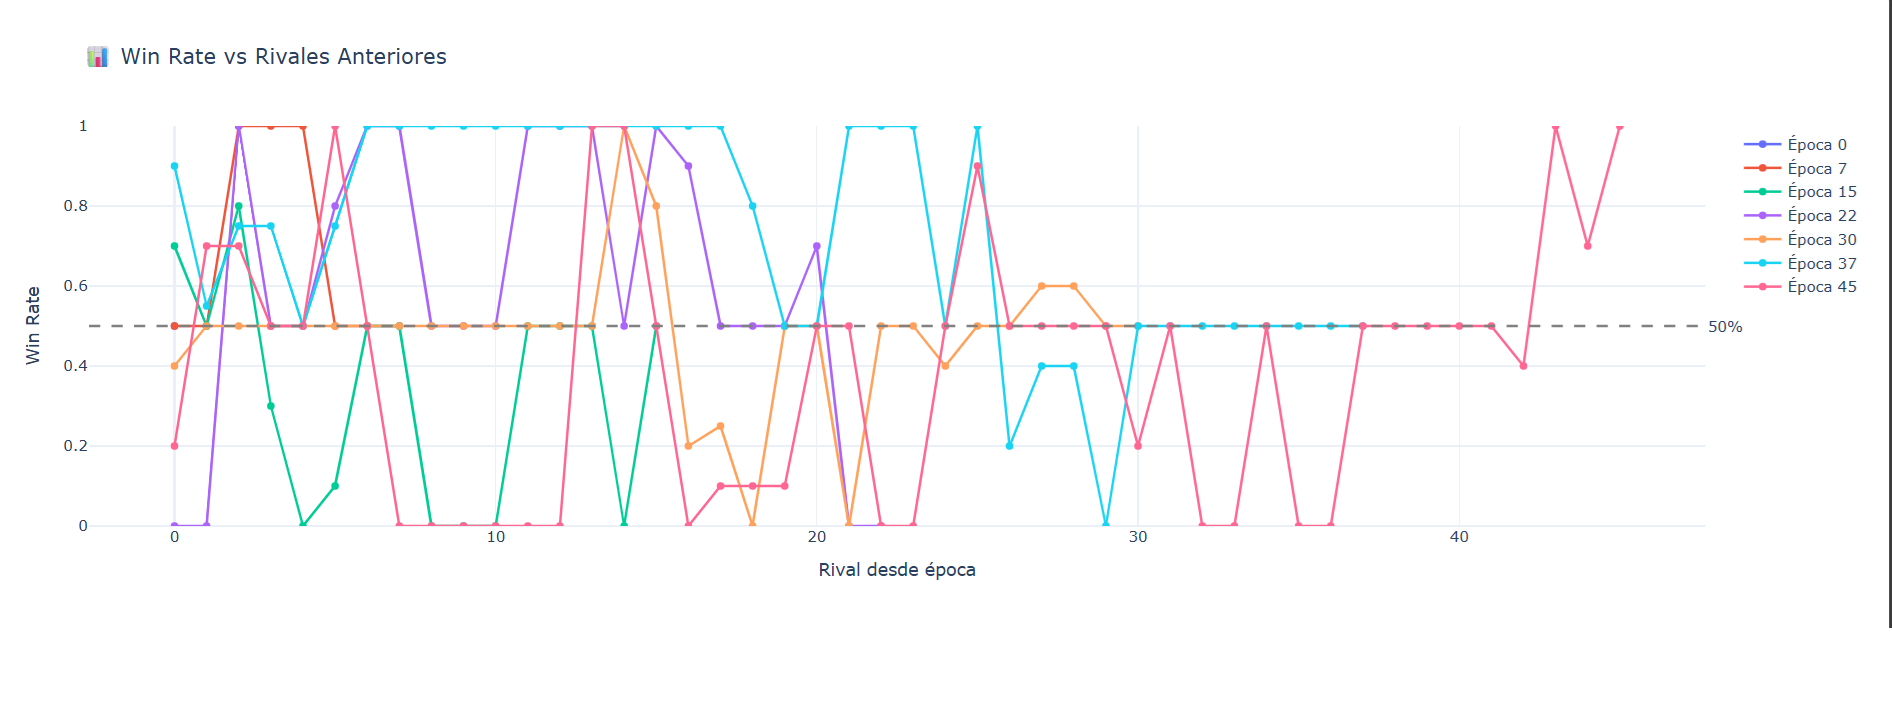

In [18]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/WinRateBitacora1.png'))

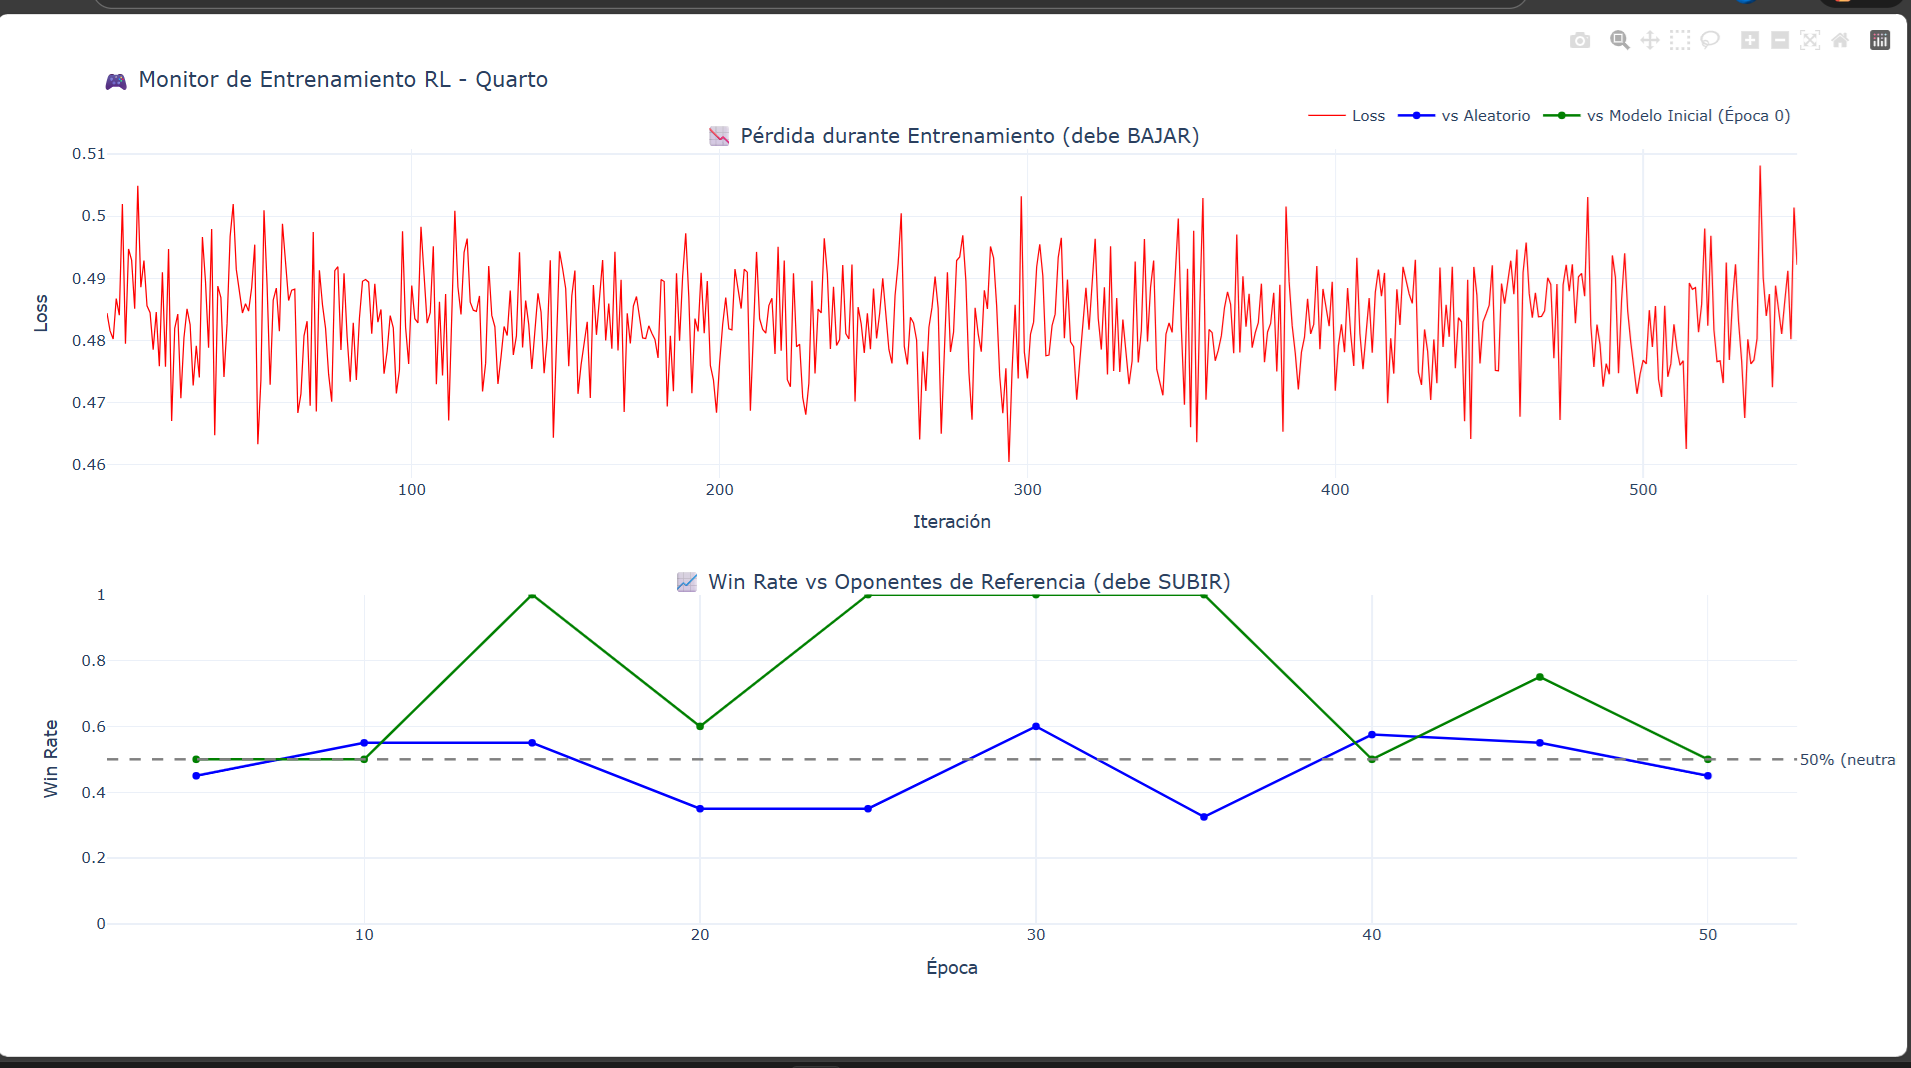

In [17]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/Implementacion de las graficas en el entrenamiento para tomar decisiones de mejora.png'))

### Conclusiones de la Bitacora 1
- Se detecto los problemas en el entrenamiento ya que no hay muchas mejoras...
1. Loss estancado (~0.48-0.49):
El loss oscila sin tendencia descendente, indicando que el modelo no está aprendiendo efectivamente
Valor cercano a 0.5 sugiere que la red predice casi aleatoriamente (50/50)
2. Win Rate inestable:
Fluctuaciones extremas (0% a 100%) indican olvido catastrófico: al aprender contra un oponente, olvida cómo ganar a otros
No hay mejora consistente sobre el 50%
3. Causas principales:
Learning rate inadecuado: demasiado alto causa oscilaciones, muy bajo impide aprendizaje
Replay buffer insuficiente: experiencias no diversas
Arquitectura de red simple: capacidad limitada para representar estrategias complejas
Función de recompensa poco informativa: solo recompensa victoria/derrota final

### Posibles soluciones para mejorar el entrenamiento (Segui)
1. Ajustar Hiperparámetros
Reducir learning_rate a 1e-4 o 5e-5
Aumentar batch_size a 128-256
Aumentar buffer_size a 50000-100000
Usar gamma más alto (0.99) para valorar recompensas futuras
2. Mejorar Arquitectura de Red
Añadir más capas ocultas (3-4 capas)
Usar Batch Normalization o Layer Normalization
Implementar redes separadas para política y valor (Actor-Critic)
3. Recompensas Intermedias
Dar recompensas por colocar piezas en posiciones estratégicas
Penalizar bloqueos del oponente no detectados
4. Estabilización del Entrenamiento
Implementar Target Network con actualizaciones suaves
Usar Gradient Clipping para evitar explosión de gradientes
Aplicar Learning Rate Scheduler con decay
5. Diversidad de Experiencias
Aumentar épocas de self-play antes de evaluar
Mezclar oponentes de diferentes épocas en el entrenamiento

### Implementacion de las correcciones y mejoras por fases

🔴 PRIORIDAD CRÍTICA (Fase 1) ✅ YA ESTABA IMPLEMENTADO
1. Target Network: `target_net = QuartoCNN()` con soft update cada N batches
2. Learning Rate: `LR = 1e-4` (AdamW optimizer)
3. Huber Loss: `nn.SmoothL1Loss()`
> **Estado:** Ya existía en trainRLCopy.py antes de las modificaciones

🟠 PRIORIDAD ALTA (Fase 2) ✅ YA ESTABA IMPLEMENTADO
1. Batch Size: `BATCH_SIZE = 256` (mayor al recomendado de 128)
2. Buffer Size: `REPLAY_SIZE = 300,000` (mayor al recomendado de 100,000)
3. Gamma: `GAMMA = 0.99`
4. Gradient Clipping: `MAX_GRAD_NORM = 1.0` con `clip_grad_norm_()`
> **Estado:** Ya existía en trainRLCopy.py antes de las modificaciones

🟡 PRIORIDAD MEDIA (Fase 3) ✅ IMPLEMENTADO - 3 Dic 2025
1. Usa temperatura: `TEMPERATURE_EXPLORE = 0.3` (antes 0.5)
2. Usa temperatura: `TEMPERATURE_EXPLOIT = 0.05` (antes 0.1)
3. BatchNormalization: Añadido `bn1, bn2, bn_fc1, bn_fc1b, bn_fc1c, bn_fc1d` en CNN1.py
4. Más capas ocultas: Arquitectura 256→256→128→64 neuronas en CNN1.py
5. Dropout: Reducido de 0.5 a 0.2 en CNN1.py
> **Archivos modificados:** trainRLCopy.py, models/CNN1.py

🟢 PRIORIDAD BAJA (Fase 4) ✅ IMPLEMENTADO - 3 Dic 2025
1. Recompensas intermedias: Centro (+0.1), Amenaza 3 en línea (+0.3), Bloqueo (+0.2) en RL_functions.py
2. Learning Rate Scheduler: `CosineAnnealingWarmRestarts(T_0=200, T_mult=2, eta_min=1e-6)` en trainRLCopy.py
3. Soft Update Target: `TAU = 0.005` (ya existía)
4. Mezclar oponentes: `SELF_PLAY_PROBABILITY = 0.5` después de época 10 en trainRLCopy.py
> **Archivos modificados:** trainRLCopy.py, QuartoRL/RL_functions.py

---
## Cambios Implementados - Fecha: 3 de Diciembre 2025

### ✅ Fase 3 Implementada

#### 3.1 Temperaturas de Exploración (trainRLCopy.py)
| Parámetro | Valor Anterior | Valor Nuevo |
|-----------|----------------|-------------|
| TEMPERATURE_EXPLORE | 0.5 | 0.3 |
| TEMPERATURE_EXPLOIT | 0.1 | 0.05 |

#### 3.2 Arquitectura de Red Mejorada (models/CNN1.py)
| Componente | Valor Anterior | Valor Nuevo |
|------------|----------------|-------------|
| Capas densas | 128 neuronas | 256→256→128→64 |
| BatchNormalization | No existía | bn1, bn2, bn_fc1, bn_fc1b, bn_fc1c, bn_fc1d |
| Dropout | 0.5 | 0.2 |

### ✅ Fase 4 Implementada

#### 4.1 Recompensas Intermedias (QuartoRL/RL_functions.py)
| Recompensa | Valor | Condición |
|------------|-------|-----------|
| Posición central | +0.1 | Colocar en posiciones 5, 6, 9, 10 |
| Crear amenaza | +0.3 | Formar línea con 3 piezas |
| Bloqueo potencial | +0.2 | Colocar en línea con 2 piezas |

#### 4.2 Learning Rate Scheduler (trainRLCopy.py)
```python
# Antes: CosineAnnealingLR(optimizer, EPOCHS, 0.0)
# Ahora:
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=200,      # Reiniciar cada 200 épocas
    T_mult=2,     # Duplicar período después de cada reinicio
    eta_min=1e-6  # LR mínimo
)
```

#### 4.3 Mezcla de Oponentes (trainRLCopy.py)
```python
MIXED_OPPONENTS_START_EPOCH = 10  # Iniciar después de época 10
SELF_PLAY_PROBABILITY = 0.5       # 50% self-play, 50% oponentes anteriores
```


### ⚠️ Notas Importantes
1. **Entrenar desde cero:** La arquitectura de la red cambió, los pesos anteriores NO son compatibles
2. **Archivos modificados:**
   - `trainRLCopy.py` - Temperaturas, LR Scheduler, Mezcla de oponentes
   - `models/CNN1.py` - Arquitectura con BatchNorm y más capas
   - `QuartoRL/RL_functions.py` - Recompensas intermedias


### Ejecutando con las mejoras hasta la epoca 100 se obtuvo una leve mejora pero aun no es suficente con el objetivo
pero almenos ya es una ganancia que la perdida durante el entrenamiento ya no este estancada en 0.48-0.49 de hecho cumple con las espectativas y ya baja acercandose al cero
-No hay mejoras en el WinRate pero se espera que en el torneo ya no gane el agente Cero y gane uno mas reciente o superior

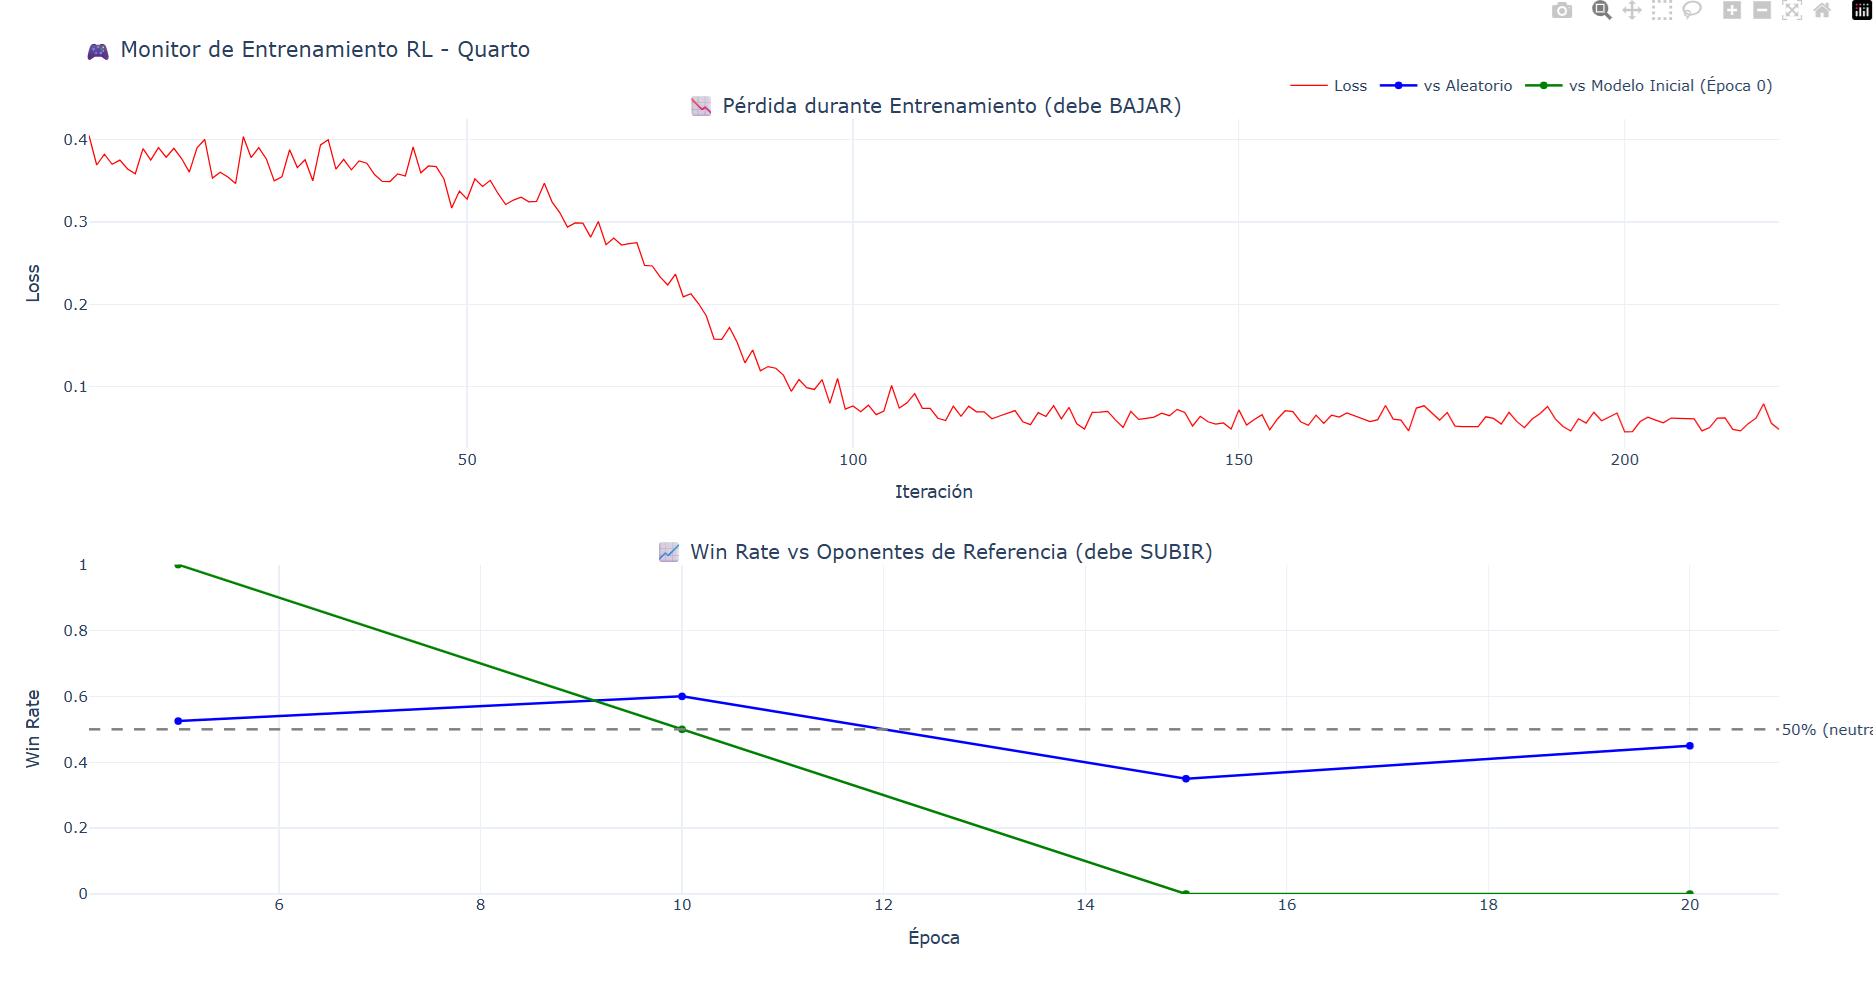

In [16]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/MejorasBitacora1.png'))

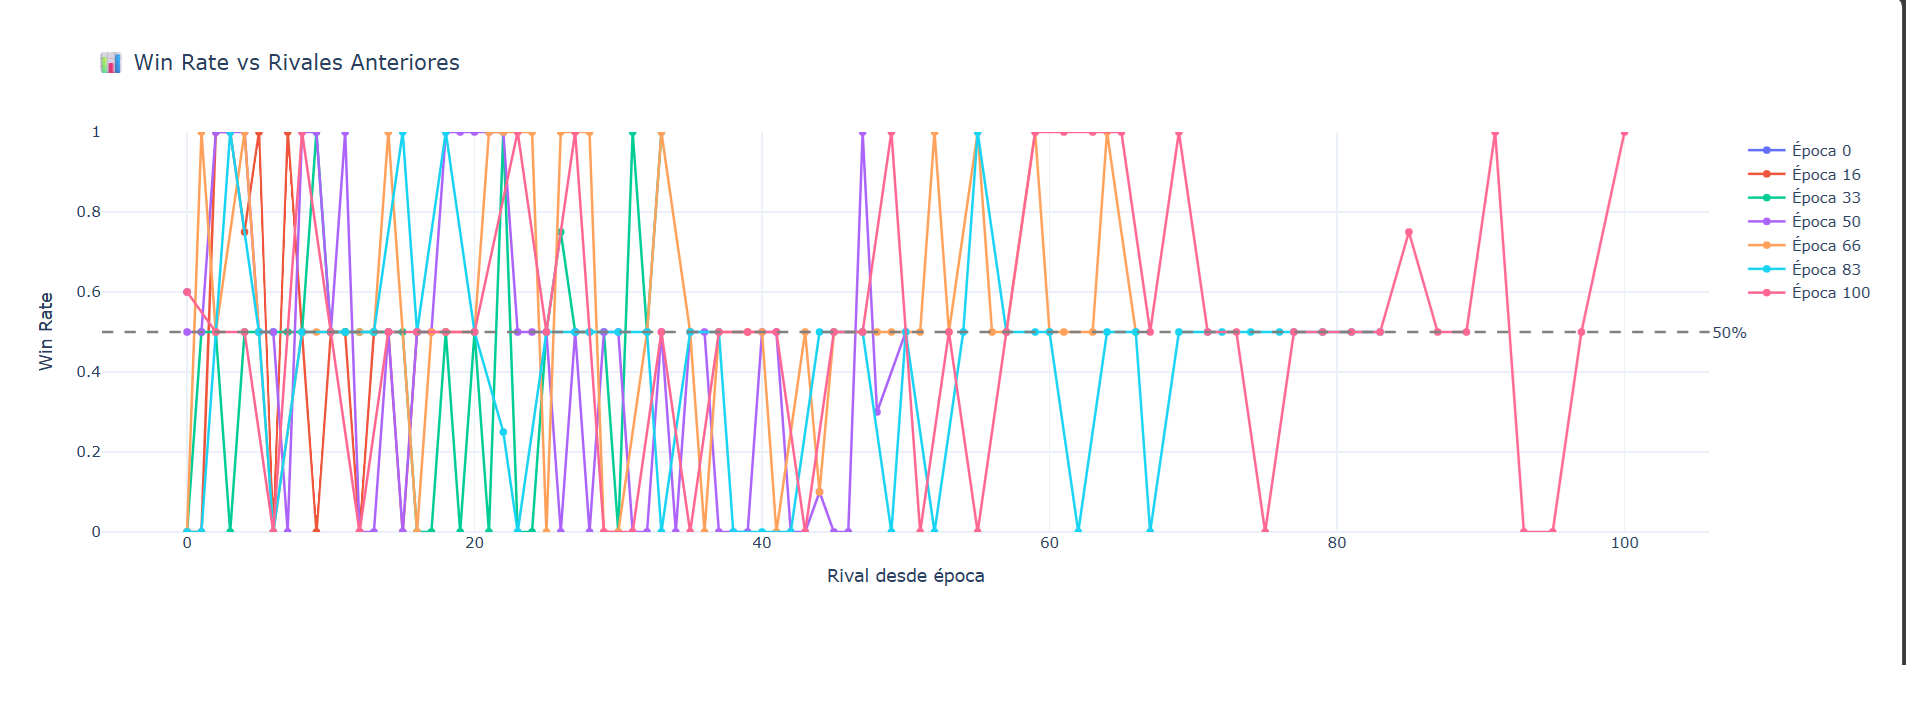

In [15]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/MejorasaparentesBitacora1.png'))

##### Hubo un punto de inflexion en la epoca 110 que el winrate empezo a mejorar manteniendose la perdida en un valor que tendia a cero, esperemos hasta la epoca 200 y se reportara denuevo

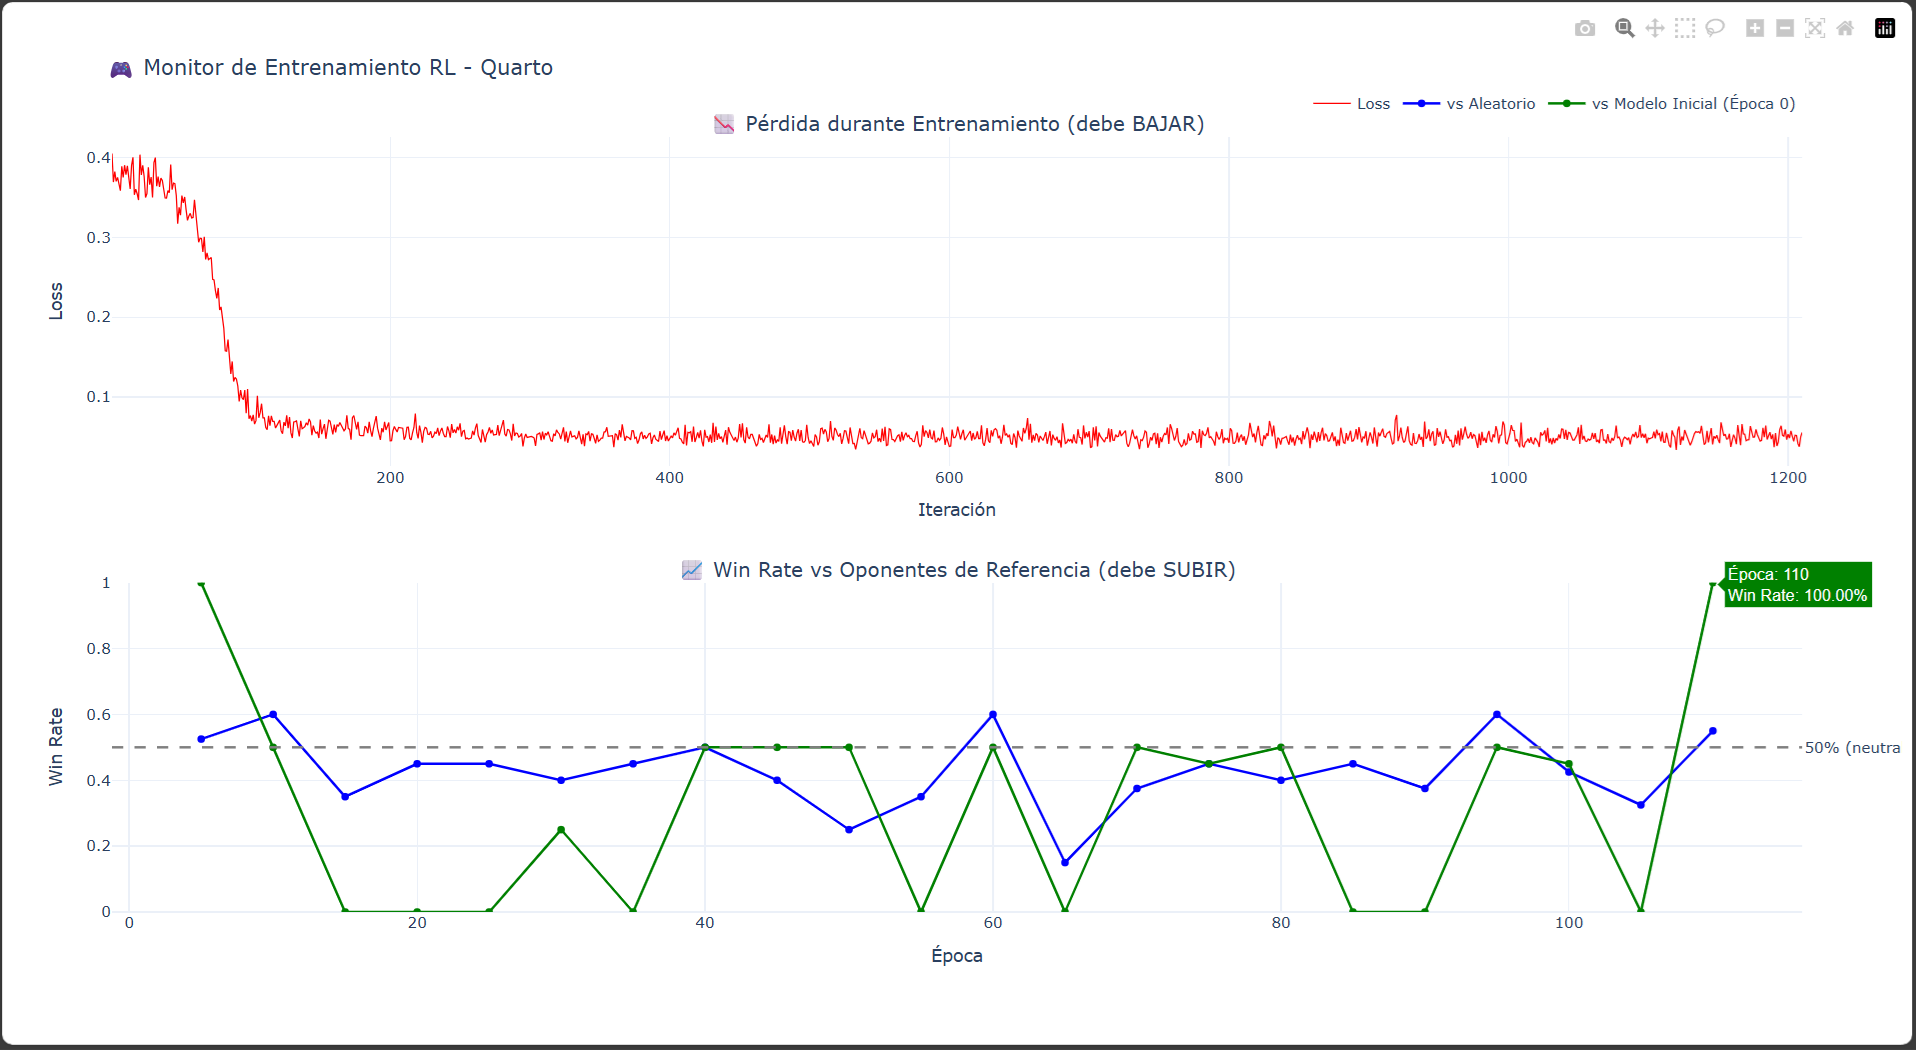

In [14]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/PuntoAparentedeInflexion.png'))

### Posibles causas qeu el winrate no mejore poco a poco
Segun Claude Opus 4.5
1. Solo entrenas la cabeza de selección de pieza, ignoras la posición

In [ ]:
# Línea ~520: Solo usas state_sel_action_values en el loss
loss = loss_fcn(
    state_sel_action_values, expected_state_action_values.unsqueeze(1)
)

# Línea ~520: Solo usas state_sel_action_values en el loss
loss = loss_fcn(
    state_sel_action_values, expected_state_action_values.unsqueeze(1)
)
Problema: state_pos_action_values (posición donde colocar) nunca se entrena. El modelo solo aprende a seleccionar piezas, no dónde colocarlas.


2. Target Q-value solo considera una cabeza

In [ ]:
# Calcular expected values para AMBAS cabezas
with torch.no_grad():
    _next_pos, _next_piece = target_net(
        next_state_board[non_final_mask], next_state_piece[non_final_mask]
    )
    next_pos_values = torch.zeros(valid_batch_size)
    next_sel_values = torch.zeros(valid_batch_size)
    next_pos_values[non_final_mask] = _next_pos.max(dim=1).values
    next_sel_values[non_final_mask] = _next_piece.max(dim=1).values

# Expected Q para ambas acciones
expected_pos_values = (next_pos_values * GAMMA) + reward
expected_sel_values = (next_sel_values * GAMMA) + reward

# Loss combinado de AMBAS cabezas
loss_pos = loss_fcn(state_pos_action_values, expected_pos_values.unsqueeze(1))
loss_sel = loss_fcn(state_sel_action_values, expected_sel_values.unsqueeze(1))
loss = loss_pos + loss_sel  # O usar pesos: 0.5 * loss_pos + 0.5 * loss_sel

Segun Claude Opus 4.5 dice que eso es el problema entonces para comprobarlo solo queda que los agentes se enfrenten en un torneo y ver si el agente tuvo una mejora notable ademas con la implementacion de una arquitectura flexible para la comparar con otros agentes de otras arquitecturas y ver cual es el mejor agente en general

Se esperara hasta la epoca 200 ya que tiene un reinicio de learning rate y se vera si hay una mejora notable en el winrate y en la perdida
y en la epoca 500 se hara una pausa para verificar si es necesario hacer mas modificaciones o si ya el agente esta listo para competir contra otros agentes en un torneo, si los resultados son estables entre el 50% a 70% de winrate se considerara que el agente esta listo para competir con otros en agentes externos

Se ha vuelto a crear de nuevo los archivos torneo.py y torneo_paralelo.py para hacer los torneos entre los agentes guardados cada 100 epocas
con temperaturas de 0.1, 0.5, 0.01 y 1

Se ha notado leves mejoras en el winrate ya que va en la epoca 200 y se acerca el 65% de winrate

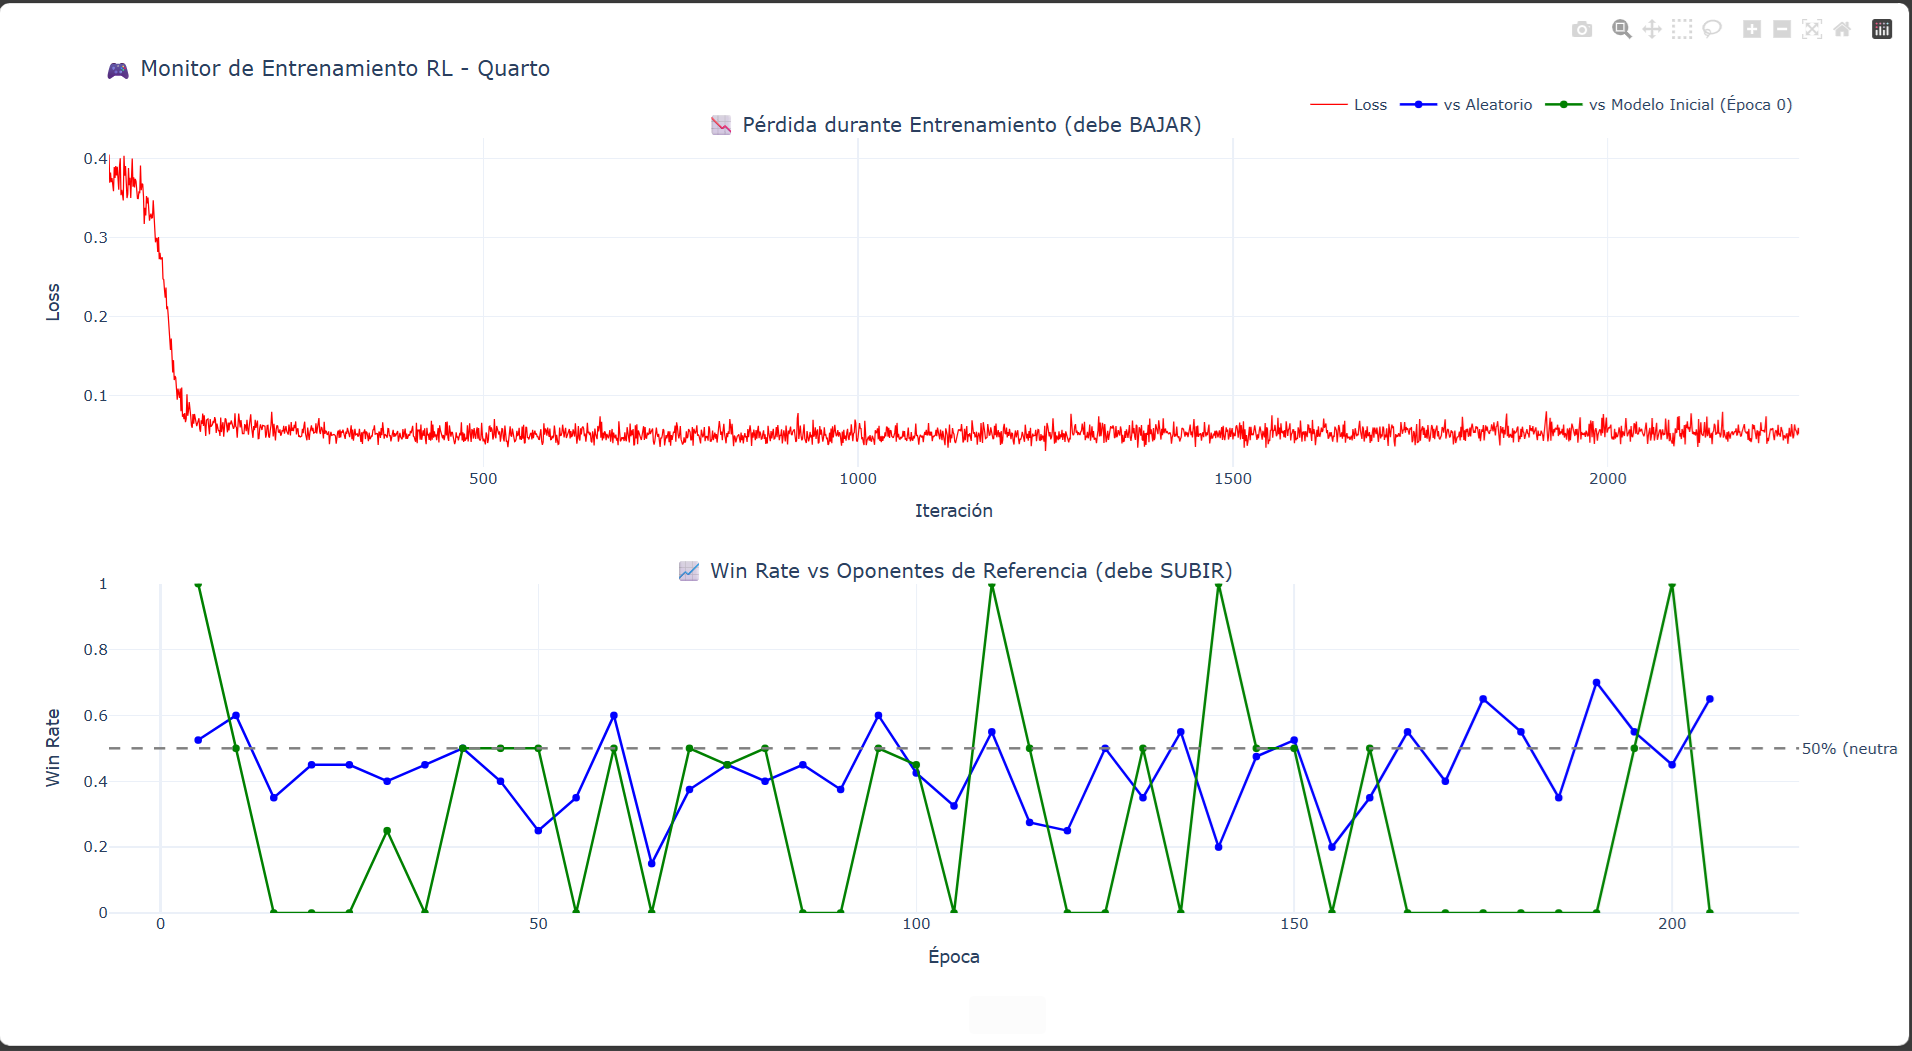

In [13]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/PosiblesMejorasWinrateBitacora1.png'))

Resultados preliminares del torneo entre los agentes que tienen el pico mas alto de winrate (linea Verde),

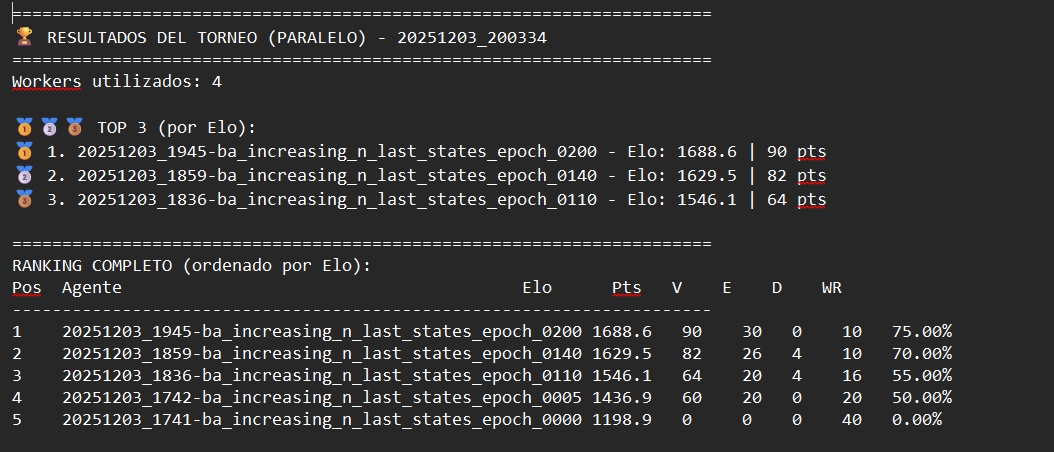

In [12]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/ResultadosPreliminaresTorneoBitacora1.png'))

Resultado del torneo contra 200 agentes entrenados hasta la epoca 200

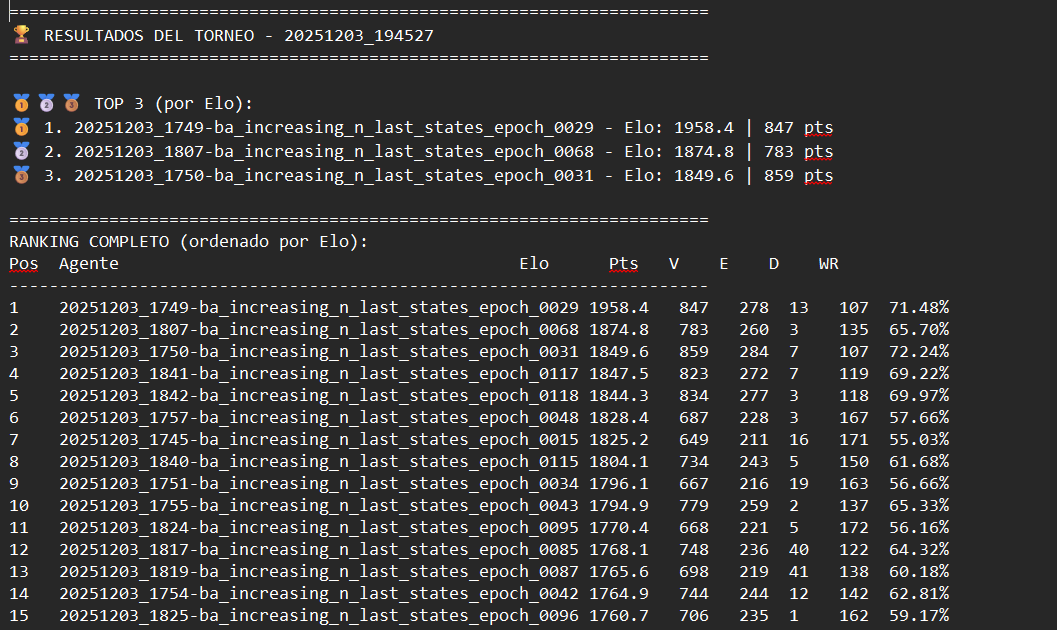

In [11]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/ResultadosTorneo200AgentesBitacora1.png'))

Hubo un fallo repentino en el entrenamiento desde cero y se corto la ejecucion del entrenamiento se uso el resume pero las graficas se peridieron asi que se guardo una copia de las graficas antes del fallo

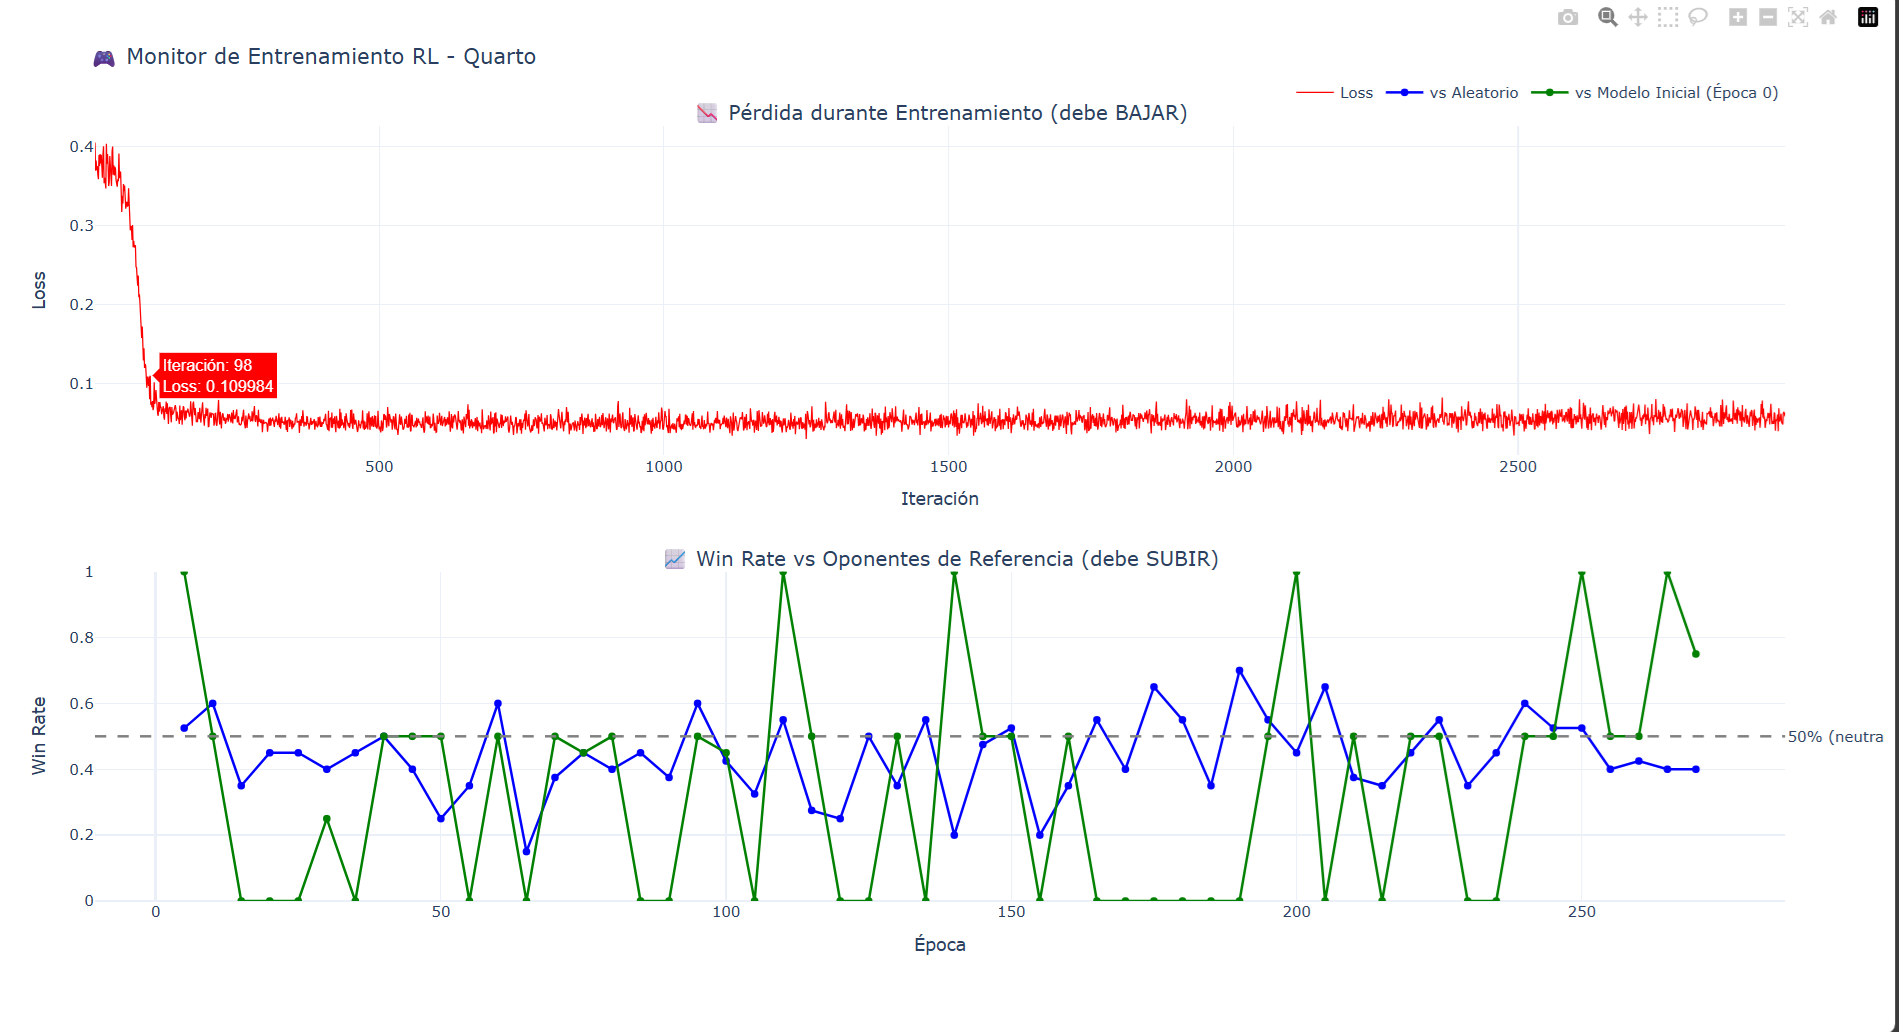

In [10]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/BackupantesFallobitacora1.png'))

#### Mejores agentes hasta ese momento 0,5,110,140,200,250,265,285, haciendo experimentos con la arquitectura BatchNorm

Duelo entre agentes de distintas arquitecturas existe inconsitencias (Aveces gana o pierde) 4-12-2025

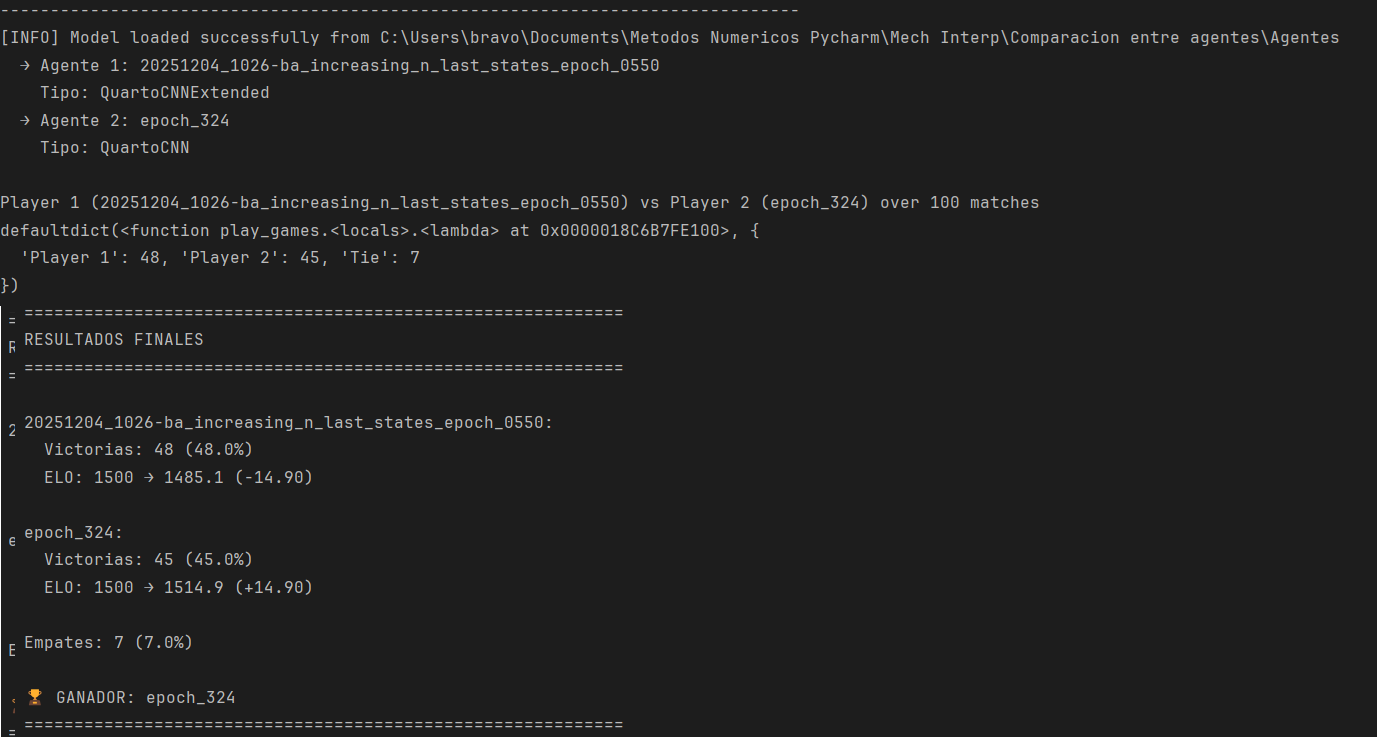

In [9]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/Dueloentreagentes1Bitacora1.png'))

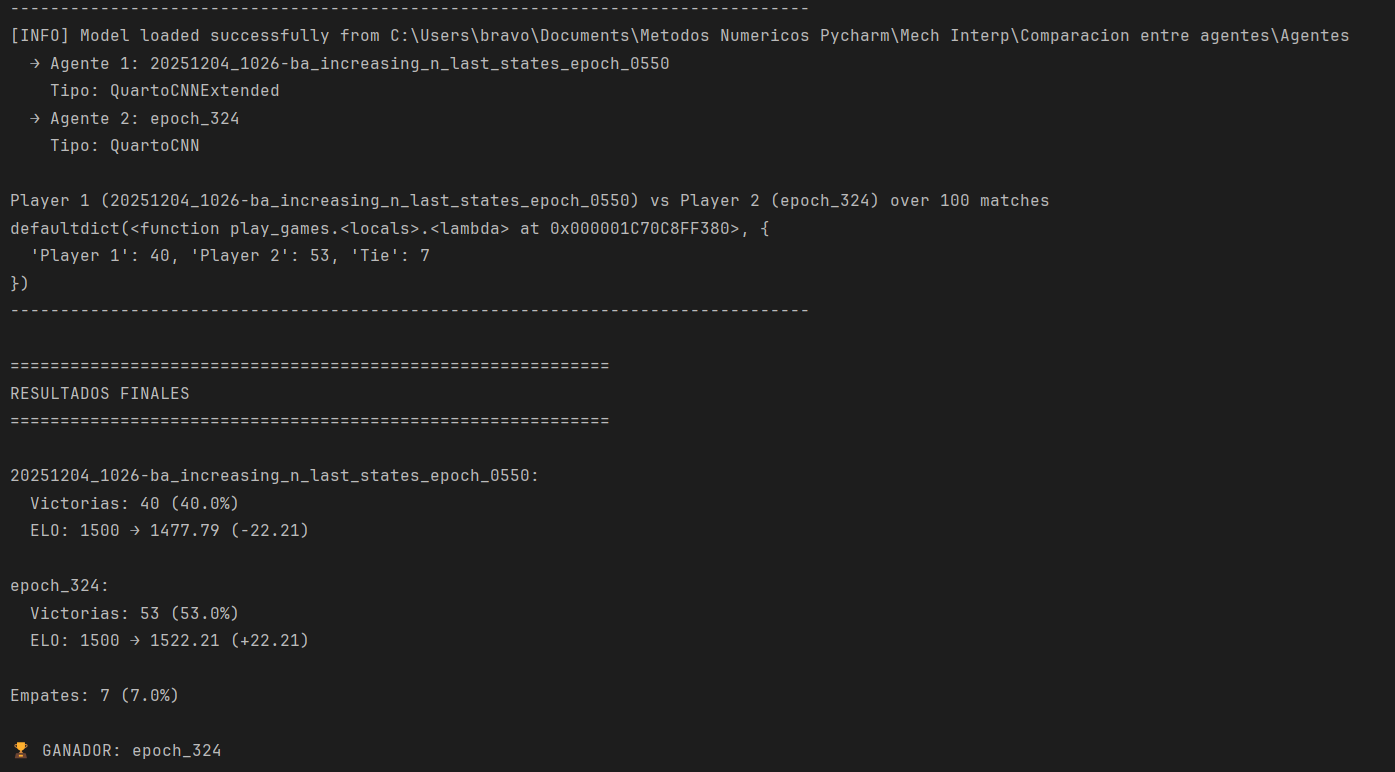

In [8]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/Dueloentreagentes2Bitacora1.png'))

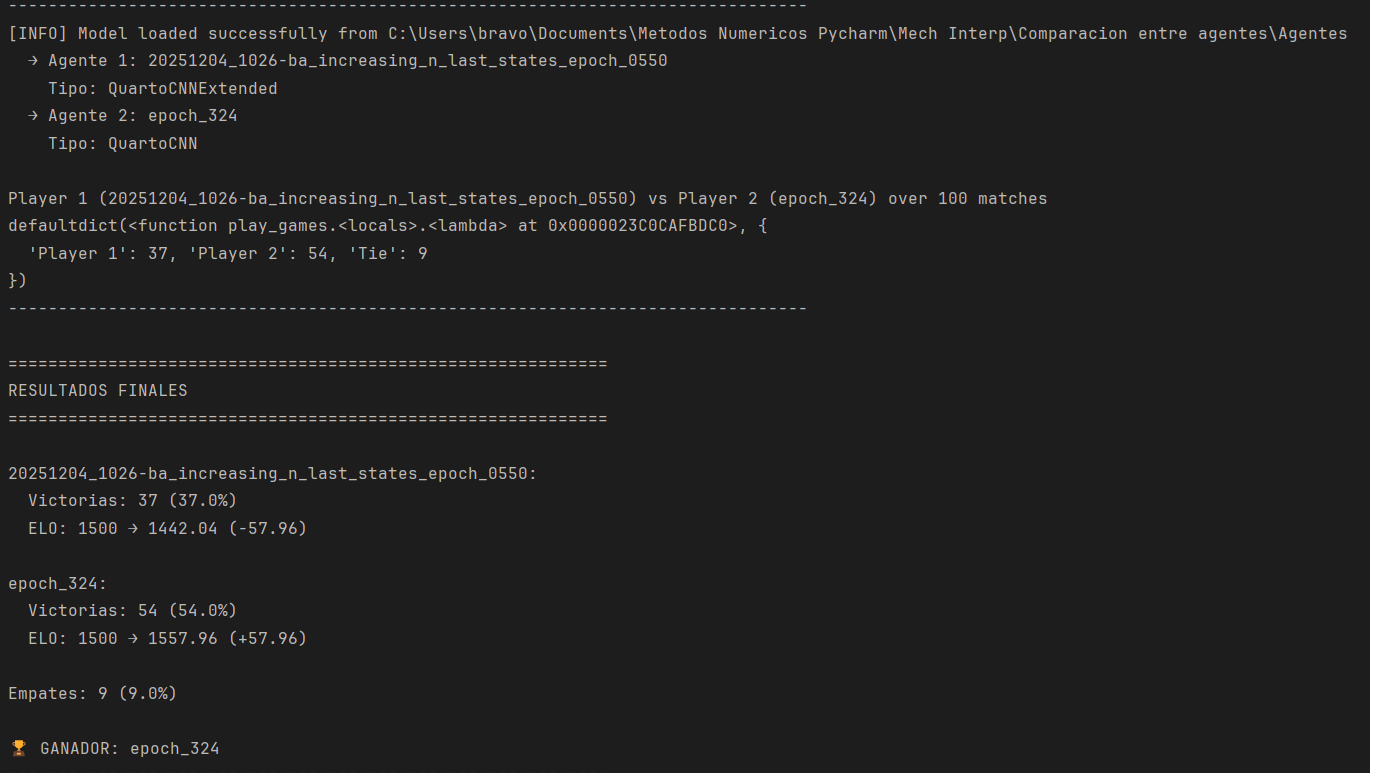

In [7]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/Dueloentreagentes3Bitacora1.png'))

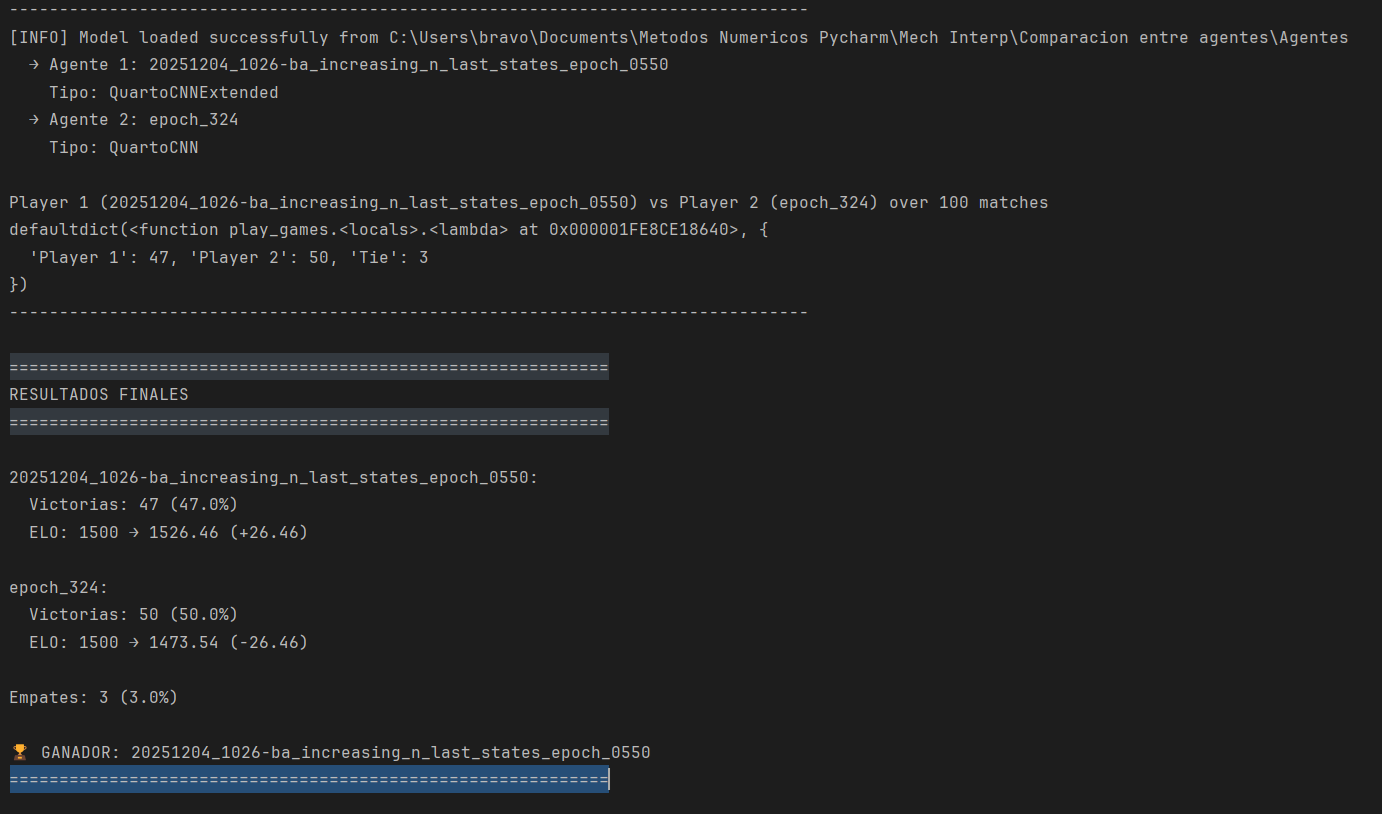

In [6]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/Dueloentreagentes4Bitacora1.png'))

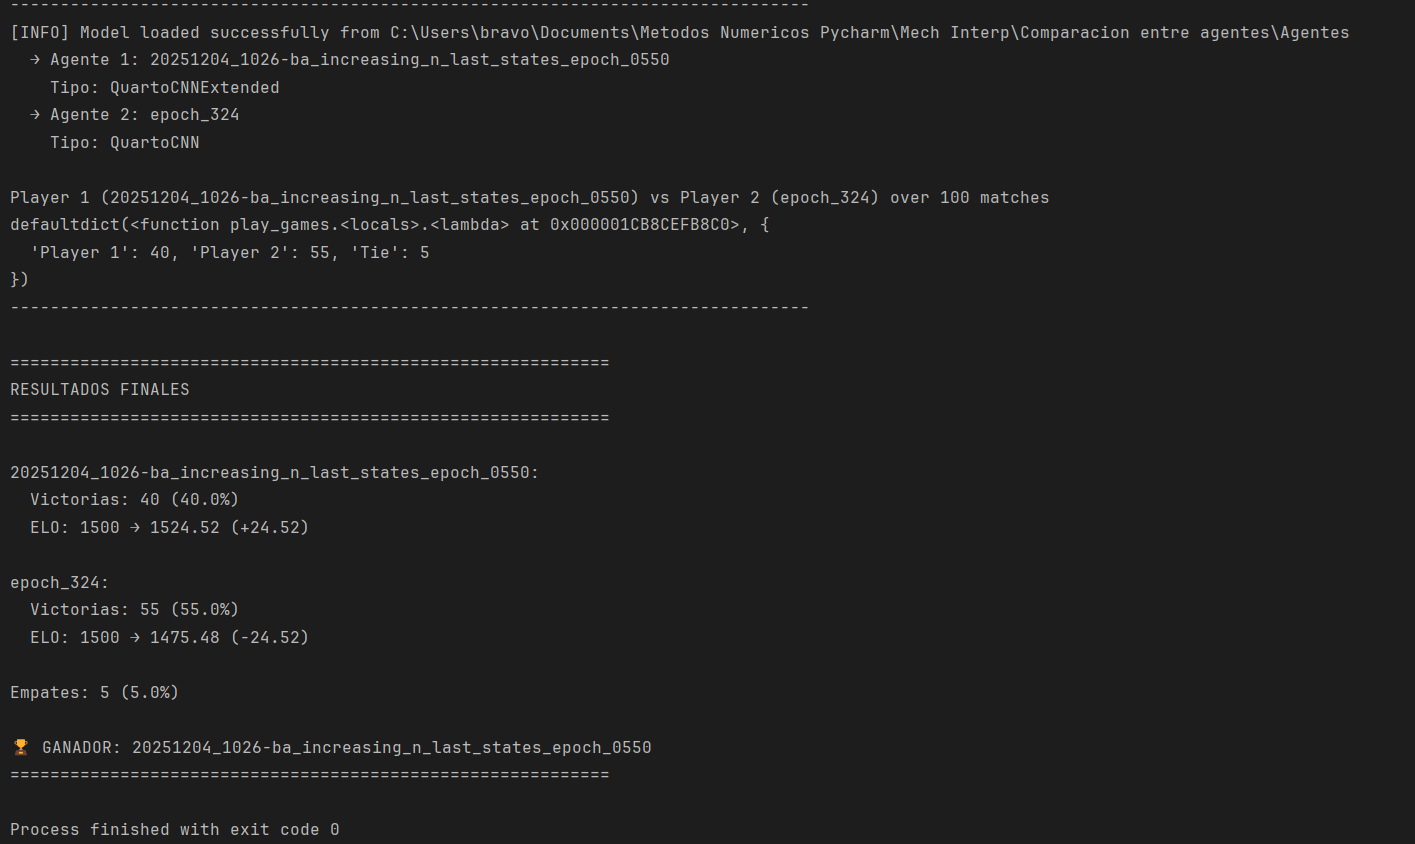

In [5]:
from IPython.display import Image, display
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/Dueloentreagentes5Bitacora1.png'))

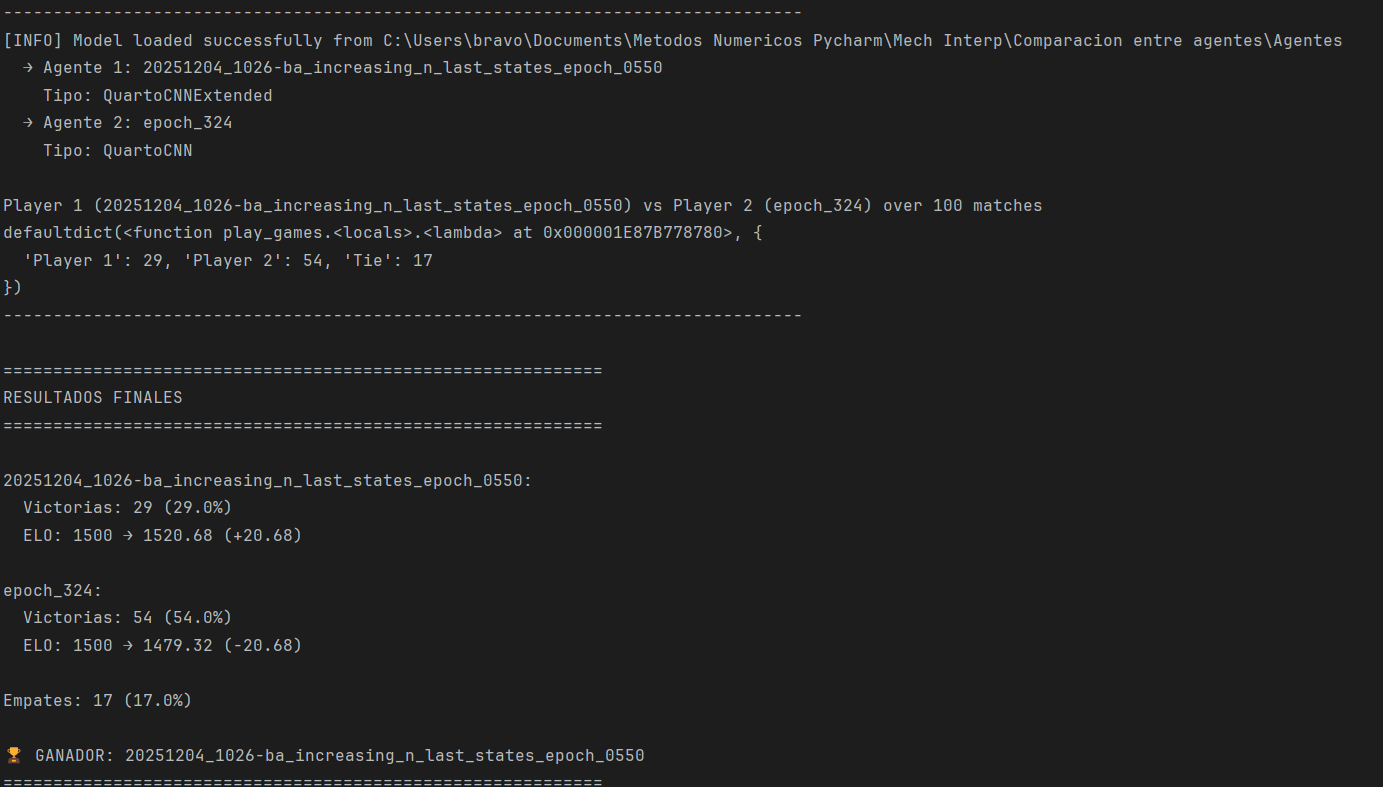

In [4]:
from IPython.display import Image, display#despues de 3 mas
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/Dueloentreagentes6Bitacora1.png'))

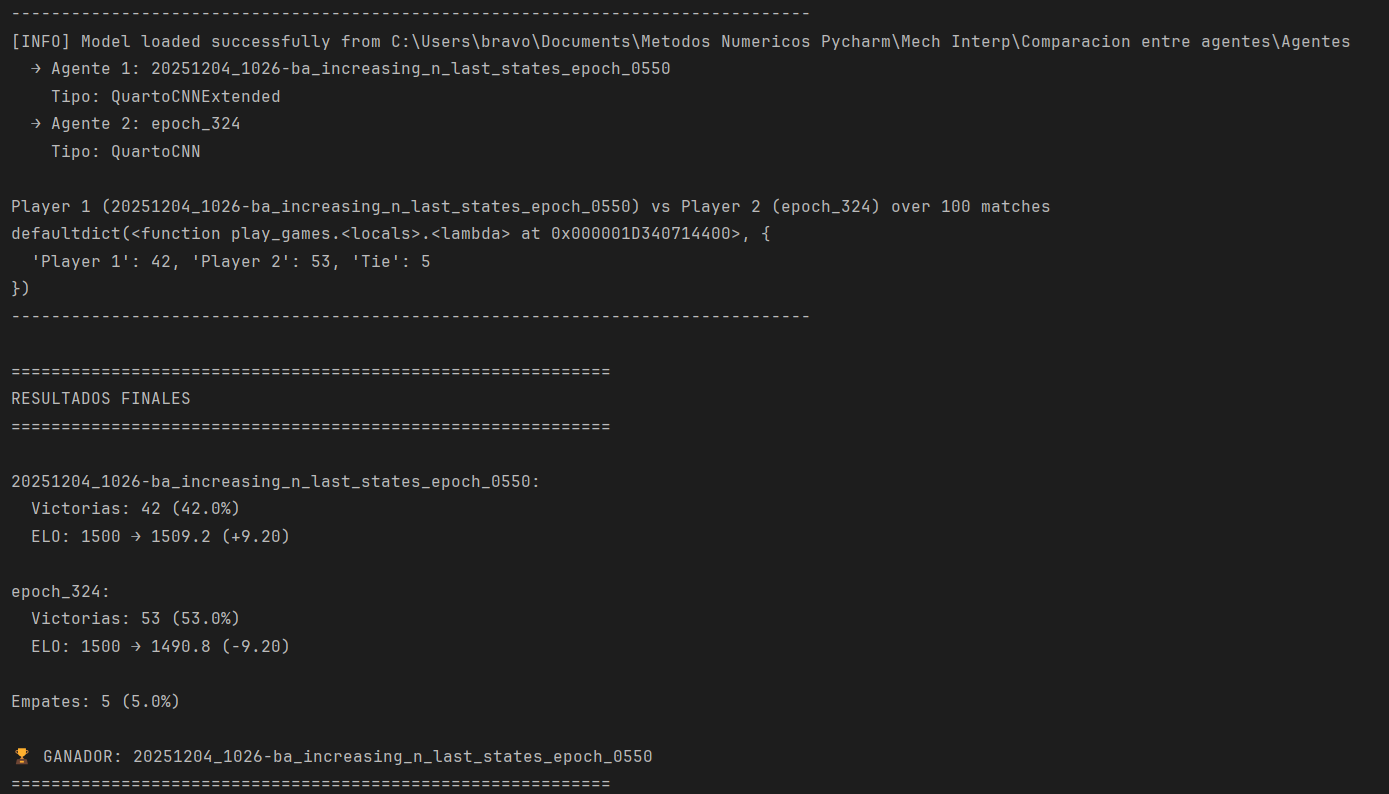

In [3]:
from IPython.display import Image, display#luego de uno mas
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/Dueloentreagentes7Bitacora1.png'))

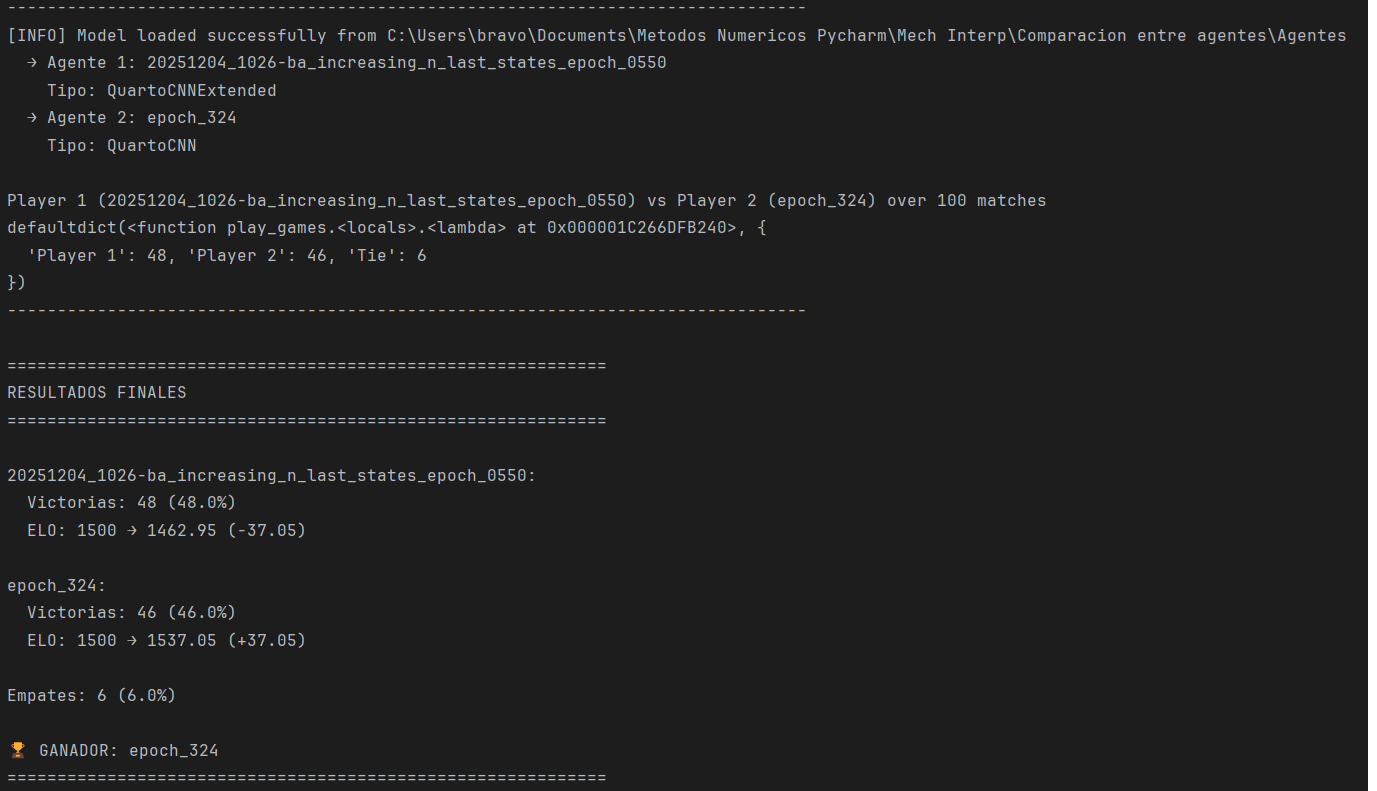

In [2]:
from IPython.display import Image, display #hasta que sucedio
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/Dueloentreagentes8Bitacora1.png'))

Y se repetio el bucle 12 intentos

Se ha notado una mejora Considerable en el entrenamiento ya que el agente #625 vs el agente 550 ha mejorado considerablemente en el torneo contra el agente epoch_324 su tasa de victorias son mas consistentes con 6 de 12 victorias o un 50% a diferencia con el agente 550 4 victorias de 12 o un 33.33%

 Duelo entre agentes — Bitácora

 Resumen de lo implementado:
 - Búsqueda y carga de `checkpoints` desde `C:\Users\bravo\Documents\Metodos Numericos Pycharm\Mech Interp\DatosEntrenamientoDev\checkpoints\QuartoCNN1`
 - Modo torneo: Todos contra todos / Grupo / Duelo (exactamente 2 agentes)
 - Ejecución paralela con selección de número de núcleos
 - Captura de errores al cargar modelos (p.ej. mismatched `state_dict` keys)
 - Registro de resultados y logs en carpeta `Resultados` o `Resultados/notebook_logs`
 - Visualizaciones: progreso de partidas, resumen de agentes participantes

 Notas encontradas en ejecución:
 - Error `Unexpected key(s) in state_dict` al cargar `QuartoCNN` (información guardada en logs)
 - `ValueError: Se necesitan exactamente 2 agentes para el duelo` (capturado)



Código: ejecutar el script del torneo/duelo y capturar salida

 Ajusta `script_path` y `work_dir` según tu proyecto.

In [ ]:
import subprocess
import os
from datetime import datetime
import json
import re
from pathlib import Path

def run_duelo(script_path, args=None, work_dir=None, save_dir=None, python_exe=None, timeout=None):
    """
    Ejecuta `script_path` (p.ej. `torneo_paralelo.py`) y guarda stdout/stderr en `save_dir`.
    Devuelve dict con returncode, stdout, stderr y ruta del log.
    """
    python_exe = python_exe or os.sys.executable
    args = args or []
    cmd = [python_exe, str(script_path)] + args
    if work_dir:
        work_dir = Path(work_dir)
    save_dir = Path(save_dir or Path.cwd() / "Resultados" / "notebook_logs")
    save_dir.mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file = save_dir / f"duelo_run_{ts}.log"
    try:
        proc = subprocess.run(cmd, cwd=work_dir, capture_output=True, text=True, timeout=timeout)
        out = proc.stdout
        err = proc.stderr
        combined = f"--- STDOUT ---\n{out}\n\n--- STDERR ---\n{err}\n"
        log_file.write_text(combined, encoding="utf-8")
        return {"returncode": proc.returncode, "stdout": out, "stderr": err, "log_path": str(log_file)}
    except subprocess.TimeoutExpired as e:
        note = f"TIMEOUT: {e}\n"
        log_file.write_text(note, encoding="utf-8")
        return {"returncode": None, "stdout": "", "stderr": note, "log_path": str(log_file)}


Código: parsear el log para extraer errores y métricas clave


In [ ]:
def parse_log_text(text):
    summary = {}
    m_agents = re.search(r"Agentes participantes:\s*(\d+)", text)
    if m_agents:
        summary["agentes_participantes"] = int(m_agents.group(1))
    m_total = re.search(r"Total enfrentamientos:\s*([\d,]+)", text)
    if m_total:
        summary["total_enfrentamientos"] = int(m_total.group(1).replace(",", ""))
    if "Unexpected key(s) in state_dict" in text or "Error(s) in loading state_dict" in text:
        summary.setdefault("errores", []).append("state_dict_mismatch")
        keys = re.findall(r'"([^"]+)"', text)
        summary["state_dict_unexpected_keys_sample"] = keys[:20]
    if "Se necesitan exactamente 2 agentes para el duelo" in text:
        summary.setdefault("errores", []).append("necesita_exactamente_2_agentes")
    m_cpu = re.search(r"Núcleos físicos:\s*(\d+)\s*.*Núcleos totales\s*\(lógicos\):\s*(\d+)", text, re.S)
    if m_cpu:
        summary["nucleos_fisicos"] = int(m_cpu.group(1))
        summary["nucleos_logicos"] = int(m_cpu.group(2))
    return summary

Guardar resumen JSON junto al log

In [ ]:
def save_summary(summary, log_path):
    p = Path(log_path)
    summary_path = p.with_suffix(".summary.json")
    summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
    return str(summary_path)

Visualización básica: progreso y resumen (intentar leer resultados si existen)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def try_plot_results_dir(results_dir):
    results_dir = Path(results_dir)
    all_logs = list(results_dir.glob("**/*.log")) + list(results_dir.glob("**/*.txt"))
    if not all_logs:
        print("No se encontraron logs en", results_dir)
        return
    last = max(all_logs, key=lambda p: p.stat().st_mtime)
    text = last.read_text(encoding="utf-8")
    agentes = re.findall(r"Agente cargado:\s*([^\n\r]+)", text)
    if agentes:
        df = pd.Series(agentes).value_counts().rename_axis("agente").reset_index(name="cargas")
        ax = df.plot.bar(x="agente", y="cargas", figsize=(10,4), legend=False)
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Cargas detectadas en {last.name}")
        plt.tight_layout()
        plt.show()
    else:
        print("No se detectaron líneas `Agente cargado:` en el log elegido.")


Ejemplo: flujo completo (ajusta rutas y descomenta para ejecutar)



In [ ]:
script_path = Path(r"C:\Users\bravo\Documents\Metodos Numericos Pycharm\Mech Interp\hierarchical-SAE\torneo_paralelo.py")
work_dir = script_path.parent
run_res = run_duelo(script_path, args=["--modo","3","--partidas","10"], work_dir=work_dir, timeout=7200)
log_path = run_res["log_path"]
 text = Path(log_path).read_text(encoding="utf-8")
 summary = parse_log_text(text)
 save_summary(summary, log_path)
 try_plot_results_dir(Path(r"C:\Users\bravo\Documents\Metodos Numericos Pycharm\Mech Interp\hierarchical-SAE\Resultados"))


Registro manual de acciones realizadas

 - Fecha y hora de la ejecución: usar la celda anterior para registrar automáticamente.
 - Errores encontrados:
   - `Unexpected key(s) in state_dict` al cargar `QuartoCNN` (guardar `state_dict` y revisar arquitectura del modelo o usar `strict=False` al `load_state_dict`).
   - `ValueError: Se necesitan exactamente 2 agentes para el duelo` (verificar número de archivos seleccionados o modo).
 - Decisiones tomadas:
   - Ejecutar torneos `Todos contra todos` primero para validar integridad de `checkpoints`.
   - Corregir mismatch del modelo comparando nombres de capas en entrenamiento vs. en runtime.

 Guarda este notebook como registro permanente en la carpeta `Resultados/notebook_logs`.

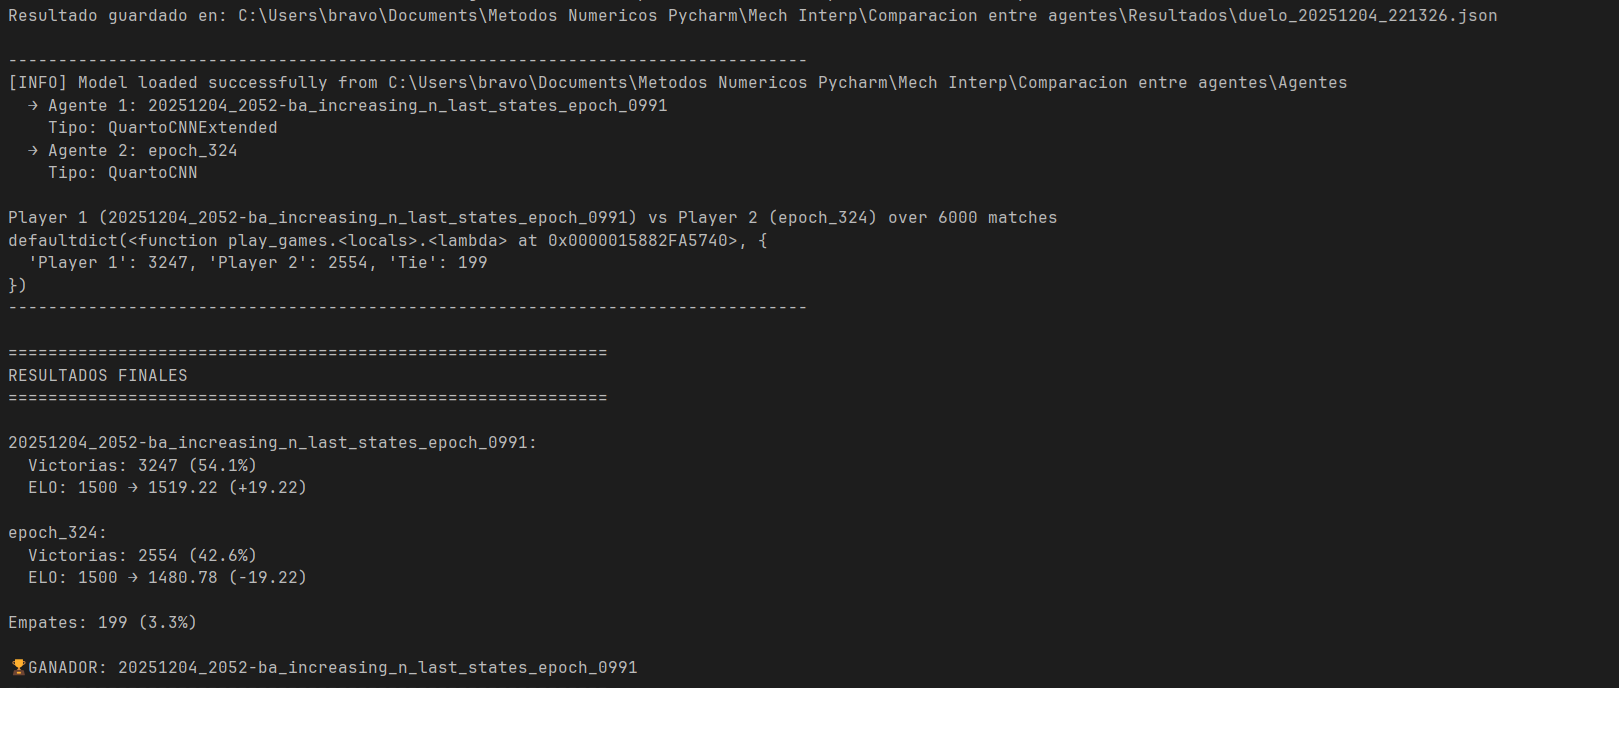

In [1]:
from IPython.display import Image, display #hasta que sucedio despues de las mil epocas el win rate va mejorando y subiendo poco a poco
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/Dueloentreagentes10Bitacora1.png'))

Luego de las que rebasase las 1000 epocas el Win Rate comenzo a mejorar poco a poco

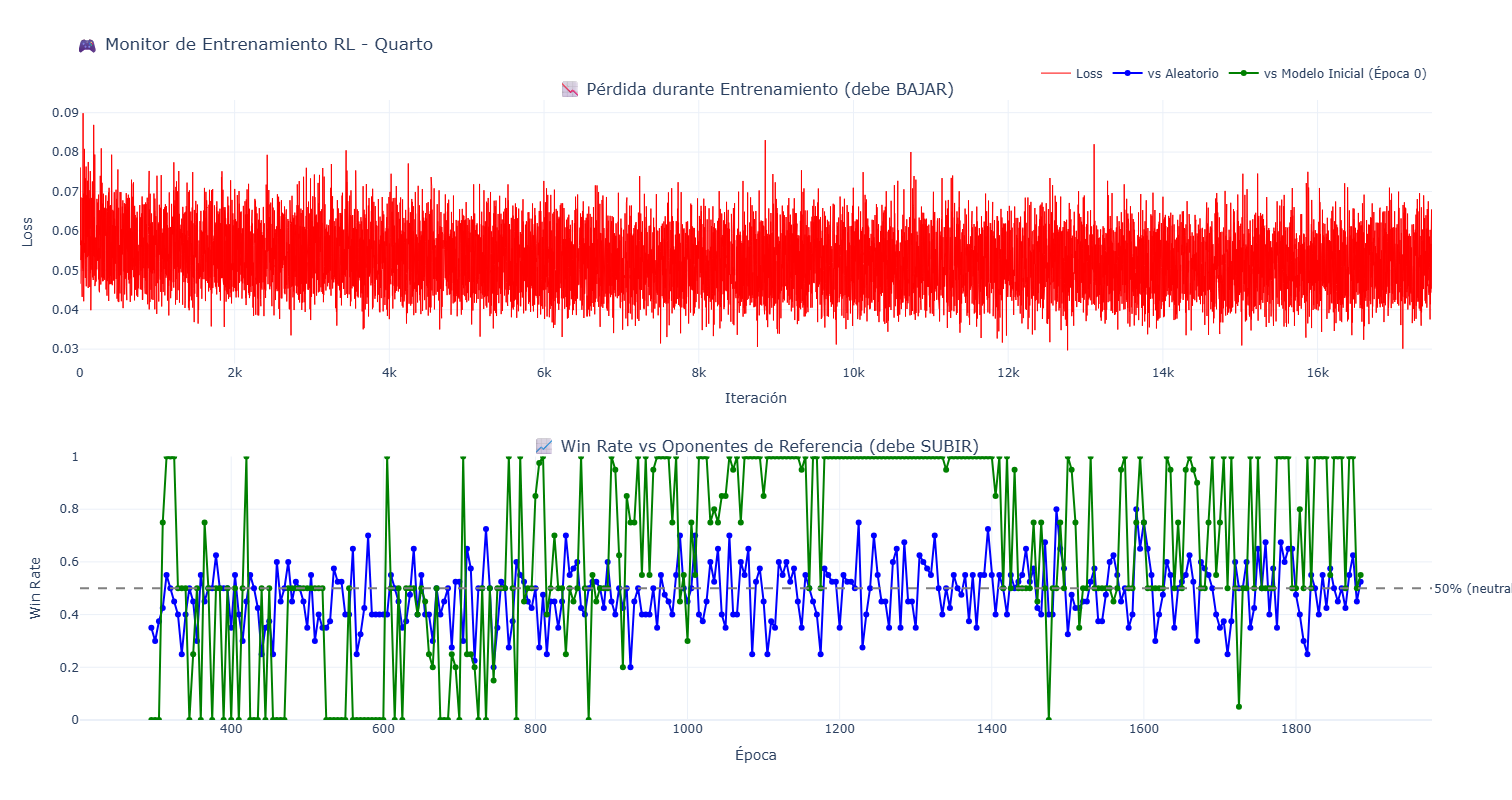

In [4]:
from IPython.display import Image, display #hasta que sucedio despues de las mil epocas el win rate va mejorando y subiendo poco a poco
display(Image('C:/Users/bravo/Documents/Metodos Numericos Pycharm/Mech Interp/Imagenes de las bitacoras/newplotBitacora1.png'))
#5/12/2025